# AI Code Trust Pipeline: results walkthrough on the prepared data

**Question:** given a piece of AI-generated code, can a model decide whether to trust it *before* anyone
runs the hidden test suite? The output is **APPROVED / REJECTED / NEEDS HUMAN REVIEW**.

This notebook walks through every stage of the pipeline using the **finished full MBPP run** in
`artifacts_pilot_openai/`: 968 problems, 38,720 `gpt-4o-mini` candidates, real human review.

- **No OpenAI calls and no regeneration.** Generation (about 4.7 hours) and test execution (about
  18 minutes) are not rerun; their saved outputs are loaded.
- **Everything runs in under a minute.** The only slow step, retraining (about 4 minutes), is off by
  default (`RETRAIN = False`).
- **Design principles:**
  - Labels come from hidden tests plus a security scan, never from AI judgement.
  - Features only use information available at decision time; hidden-test results are never features.
  - Humans validate the labels; they don't produce training data.
  - Splits are grouped by problem, so there is no leakage.

To regenerate or relabel, use the command-line stages (`uv run trust-pipeline ...`, see
`run_openai.md`). This notebook only reads their outputs.

## 0. Setup

Run locally from the project folder with `uv run --extra notebook jupyter lab`, or open the notebook in
Cursor or VS Code with the project's `.venv` as the kernel.

In [1]:
import json
import os
import sys
import time
from pathlib import Path

# Find the project folder (the one containing trust_pipeline/), wherever the kernel was started.
IN_COLAB = "google.colab" in sys.modules
_starts = [Path(os.environ["MLE_PROJECT_ROOT"])] if os.environ.get("MLE_PROJECT_ROOT") else []
if "__vsc_ipynb_file__" in globals():  # set by Cursor / VS Code: the notebook's own path
    _starts.append(Path(__vsc_ipynb_file__).parent)
_starts += [Path.cwd(), Path.home() / "MLE_NEW", Path("/content/MLE_NEW"), Path("/content/drive/MyDrive/MLE_NEW")]
PROJECT_ROOT = next((p for start in _starts for p in [start, *start.parents]
                     if (p / "trust_pipeline").is_dir()), None)
if PROJECT_ROOT is None:
    print("Kernel location:", {"python": sys.executable, "cwd": os.getcwd(), "home": str(Path.home()),
                               "colab": IN_COLAB})
    hint = ("In Colab, upload and unzip the project (see run_in_colab.md), then run "
            "%cd /content/MLE_NEW and rerun this cell."
            if IN_COLAB else
            "This kernel is not running inside the MLE_NEW folder. In Cursor, select the kernel "
            "/Users/hatem/MLE_NEW/.venv/bin/python, or set os.environ['MLE_PROJECT_ROOT'] to the folder.")
    raise RuntimeError("Can't find the project folder (the one containing trust_pipeline/). " + hint)
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

expected_python = PROJECT_ROOT / ".venv" / "bin" / "python"
if expected_python.exists() and Path(sys.executable).resolve() != expected_python.resolve():
    print(f"Note: this kernel runs {sys.executable}.\n"
          f"If an import fails below, select the project kernel: {expected_python}")

import trust_pipeline  # noqa: F401
print(f"Project: {PROJECT_ROOT}  |  Python: {sys.executable}")

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display

from trust_pipeline import features, log
from trust_pipeline.config import Config
from trust_pipeline.data import read_problems
from trust_pipeline.execution import Executor
from trust_pipeline.pipeline import ArtifactPaths

pd.set_option("display.max_colwidth", 120)
log.setup_logging("info")

Project: /Users/hatem/MLE_NEW  |  Python: /Users/hatem/MLE_NEW/.venv/bin/python


### Configuration

`RETRAIN = True` reruns training, calibration, thresholds and the run report (about 4 minutes). It
**overwrites** the model and metrics in the folder; leave it off just to explore results.

In [2]:
ARTIFACTS = "artifacts_pilot_openai"   # folder written by the full OpenAI run
RETRAIN = False                        # True: retrain the trust model (~4 min, overwrites model + metrics)
RUN_EDA = True                         # rebuild the EDA figures (~5 s)

paths = ArtifactPaths(ARTIFACTS)
cfg = Config.load(os.path.join(ARTIFACTS, "config.json"))
cfg.output_dir = ARTIFACTS

needed = ["problems.json", "dataset.csv", "feature_columns.json", "metrics.json", "test_predictions.csv",
          "model_comparison.csv", "human_review_sample.csv"]
missing = [f for f in needed if not os.path.exists(os.path.join(ARTIFACTS, f))]
assert not missing, f"Missing in {ARTIFACTS}: {missing}. Run the command-line pipeline first."
MODEL_PATH = os.path.join(ARTIFACTS, "trust_model.joblib")
if not os.path.exists(MODEL_PATH):
    print("Note: trust_model.joblib is not in git (160 MB). Section 8 needs it: run "
          f"`uv run trust-train --output-dir {ARTIFACTS}` (~4 min) or set RETRAIN = True.\n")
for f in needed:
    print(f"{f:<26} {os.path.getsize(os.path.join(ARTIFACTS, f)) / 1e6:8.1f} MB")
print("\nModel settings:", [m["name"] for m in cfg.resolved_model_configs()])
print("Prompt styles: ", cfg.resolved_prompt_styles())

problems.json                   0.9 MB
dataset.csv                    27.4 MB
feature_columns.json            0.0 MB
metrics.json                    0.0 MB
test_predictions.csv            2.5 MB
model_comparison.csv            0.0 MB
trust_model.joblib            167.5 MB
human_review_sample.csv         0.1 MB

Model settings: ['gpt-4o-mini-t0.3', 'gpt-4o-mini-t1.0']
Prompt styles:  ['standard', 'signature_only', 'step_by_step', 'constrained']


## 1. Problems: visible vs. hidden tests

MBPP problems have three or more tests. The **first** is shown to the model (*visible*); the rest,
including the challenge tests, are held back (*hidden*) and only used for labelling.

In [3]:
problems = read_problems(paths.problems)
by_id = {p["task_id"]: p for p in problems}
print(f"{len(problems)} problems; hidden tests per problem: "
      f"{pd.Series([len(p['hidden_tests']) for p in problems]).describe()[['mean', 'min', 'max']].round(1).to_dict()}")

example = by_id[2] if 2 in by_id else problems[0]
print("\nTask", example["task_id"], "-", example["text"])
print("Visible test:", example["visible_tests"][0])
print("Hidden tests:", *example["hidden_tests"], sep="\n  ")

968 problems; hidden tests per problem: {'mean': 2.0, 'min': 2.0, 'max': 5.0}

Task 2 - Write a function to find the similar elements from the given two tuple lists.
Visible test: assert similar_elements((3, 4, 5, 6),(5, 7, 4, 10)) == (4, 5)
Hidden tests:
  assert similar_elements((1, 2, 3, 4),(5, 4, 3, 7)) == (3, 4)
  assert similar_elements((11, 12, 14, 13),(17, 15, 14, 13)) == (13, 14)


## 2. Sandboxed execution (quick demo)

Every candidate runs in its own Python process, with a time limit per test and a memory cap. A
correct function passes; an infinite loop times out instead of hanging the pipeline.

In [4]:
executor = Executor(item_timeout=2.0, max_workers=2, progress=False)
print(executor.execute("def add(a, b):\n    return a + b", tests=["assert add(1, 2) == 3"], probes=["add(2, 2)"]))
print(executor.execute("def add(a, b):\n    while True: pass", tests=["assert add(1, 2) == 3"]))

{'status': 'ok', 'error': '', 'tests': ['pass'], 'probes': ['4']}
{'status': 'ok', 'error': '', 'tests': ['timeout'], 'probes': []}


## 3. The dataset: generated candidates, execution labels and features

Loaded from `dataset.csv`, the output of generation, execution, static analysis and feature building.
**Trustworthy (1)** means the candidate passes every hidden test and has no medium or high Bandit
security finding.

In [5]:
start = time.time()
dataset = features.read_frame(paths.dataset)
FEATURE_COLUMNS = json.load(open(paths.feature_columns))["feature_columns"]
print(f"Loaded {len(dataset):,} candidates x {dataset.shape[1]} columns in {time.time() - start:.1f}s; "
      f"{len(FEATURE_COLUMNS)} model features")

summary = dataset.groupby(["prompt_style", "temperature"]).agg(
    candidates=("label_trustworthy", "size"),
    trustworthy=("label_trustworthy", "mean"),
    visible_pass=("visible_pass", "mean"),
    output_tokens=("gen_num_tokens", "mean"),
).round(3)
display(summary)
display(dataset["exec_status"].value_counts().to_frame("candidates"))

Loaded 38,720 candidates x 64 columns in 1.2s; 42 model features


candidates  trustworthy  visible_pass  \
prompt_style   temperature                                          
constrained    0.3                4840        0.728         0.806   
               1.0                4840        0.722         0.800   
signature_only 0.3                4840        0.551         0.589   
               1.0                4840        0.547         0.584   
standard       0.3                4840        0.740         0.820   
               1.0                4840        0.737         0.815   
step_by_step   0.3                4840        0.749         0.821   
               1.0                4840        0.741         0.815   

                            output_tokens  
prompt_style   temperature                 
constrained    0.3                 42.213  
               1.0                 42.116  
signature_only 0.3                 56.086  
               1.0                 56.757  
standard       0.3                 50.592  
               1.0                 51.182  
step_by_step   0.3                237.900  
               1.0                239.892

,candidates
exec_status,
pass,26720
wrong_output,10624
runtime_error,1301
timeout,39
syntax_error,36


### Passing the visible test is not enough

A **silent failure** passes the visible test but fails hidden tests. The visible-test-only rule would
approve all of them.

In [6]:
display(pd.crosstab(dataset["visible_pass"].map({1: "visible pass", 0: "visible fail"}),
                    dataset["label_trustworthy"].map({1: "trustworthy", 0: "not trustworthy"}), margins=True))
silent = dataset[(dataset["visible_pass"] == 1) & (dataset["label_trustworthy"] == 0)]
print(f"Silent failures: {len(silent):,} = {len(silent) / (dataset['visible_pass'] == 1).sum():.1%} of visible passes")

row = silent.iloc[0]
problem = by_id[row["task_id"]]
print(f"\nExample - task {row['task_id']}: {problem['text']}")
print("Visible test:", problem["visible_tests"][0])
print("Hidden results:", row["hidden_results"])
print(row["generated_code"])

label_trustworthy,not trustworthy,trustworthy,All
visible_pass,,,
visible fail,8898,536,9434
visible pass,3127,26159,29286
All,12025,26695,38720


Silent failures: 3,127 = 10.7% of visible passes

Example - task 5: Write a function to find the number of ways to fill it with 2 x 1 dominoes for the given 3 x n board.
Visible test: assert count_ways(2) == 3
Hidden results: ["fail", "fail"]
def count_ways(n):
    if n == 0:
        return 1
    if n == 1:
        return 1
    if n == 2:
        return 3

    dp = [0] * (n + 1)
    dp[0], dp[1], dp[2] = 1, 1, 3

    for i in range(3, n + 1):
        dp[i] = dp[i - 1] + dp[i - 2] * 2

    return dp[n]


### Features at a glance

- **Sibling agreement:** the share of other attempts at the same problem that give the same outputs
  on probe inputs. `behavior_agreement_visible` is computed only among attempts that pass the visible
  test.
- **Code structure:** AST and radon complexity.
- **Lint and security:** ruff and Bandit findings.
- **Model confidence:** token log-probabilities.

In [7]:
key = ["visible_pass", "behavior_agreement", "behavior_agreement_visible", "probe_error_frac",
       "gen_mean_logprob", "code_lines", "cc_total", "ruff_issues"]
display(dataset.groupby("label_trustworthy")[key].mean().T.rename(
    columns={0: "not trustworthy (mean)", 1: "trustworthy (mean)"}).round(3))

label_trustworthy,not trustworthy (mean),trustworthy (mean)
visible_pass,0.260,0.980
behavior_agreement,0.385,0.829
behavior_agreement_visible,0.231,0.901
probe_error_frac,0.126,0.042
gen_mean_logprob,-1.416,-0.919
code_lines,5.844,4.975
cc_total,2.945,2.483
ruff_issues,0.701,0.472


## 4. Exploratory data analysis

`trust-eda` writes 8 figures plus `eda_report.md` (tables and observations). The most useful figures
are shown here.

22:29:01  EDA on 38,720 candidates from 968 problems -> artifacts_pilot_openai/figures/eda
22:29:06  Wrote 8 figures and artifacts_pilot_openai/eda_report.md


**01_outcomes_by_config.png**

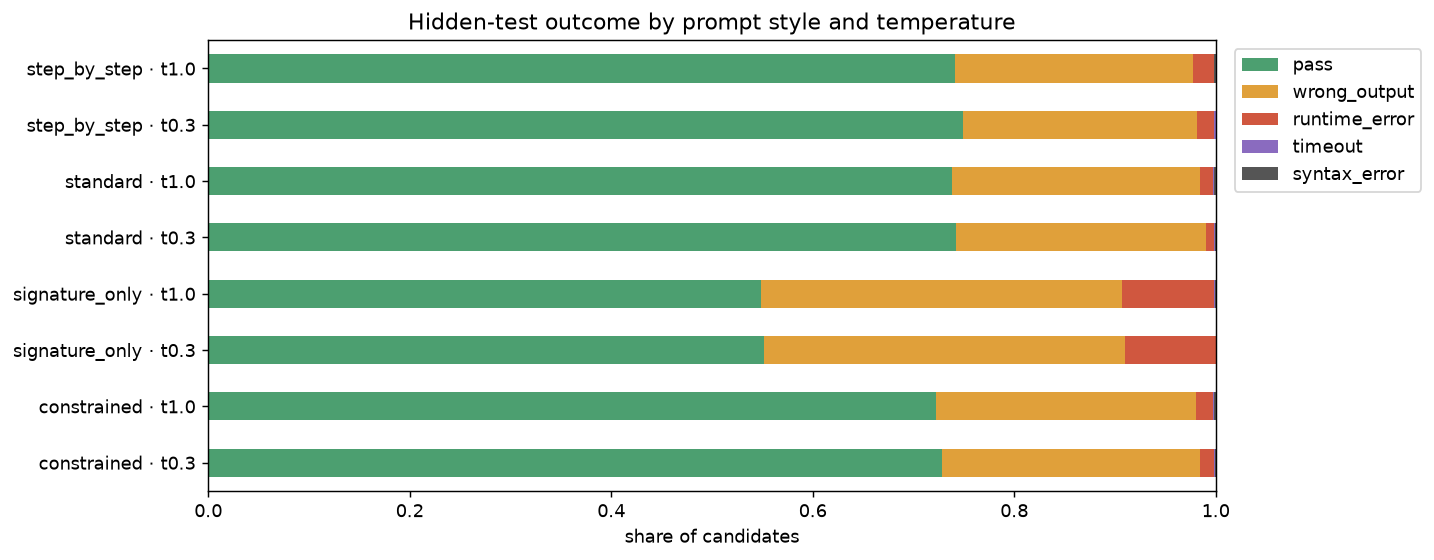

**02_trust_and_silent_failures.png**

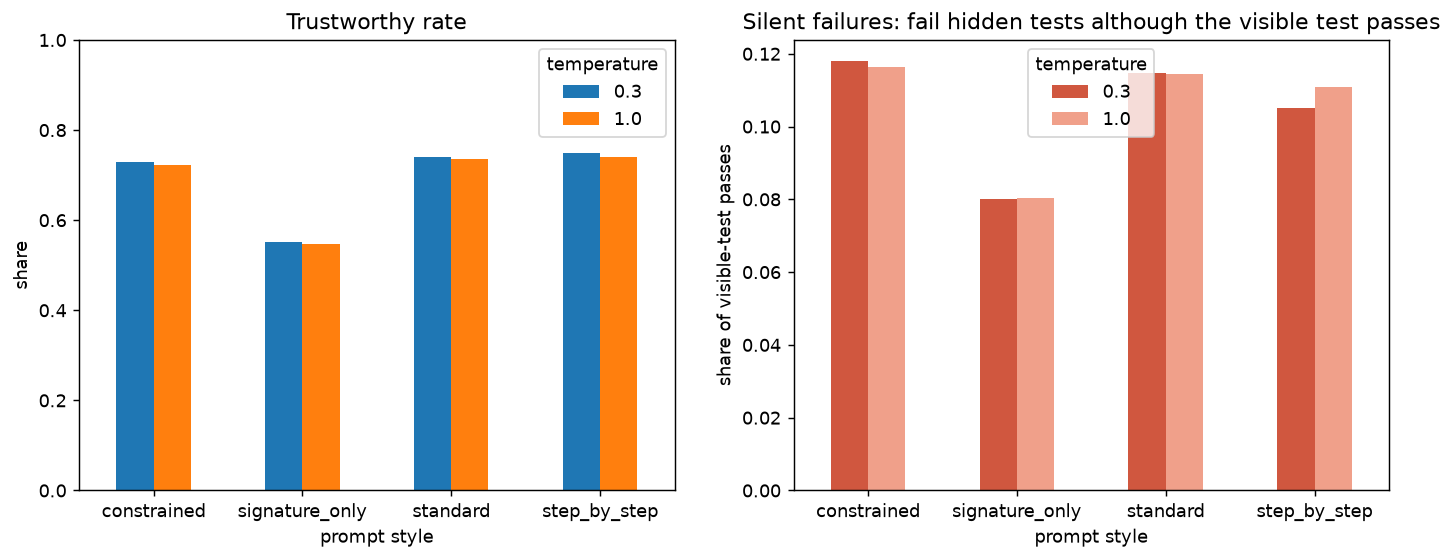

**03_problem_difficulty.png**

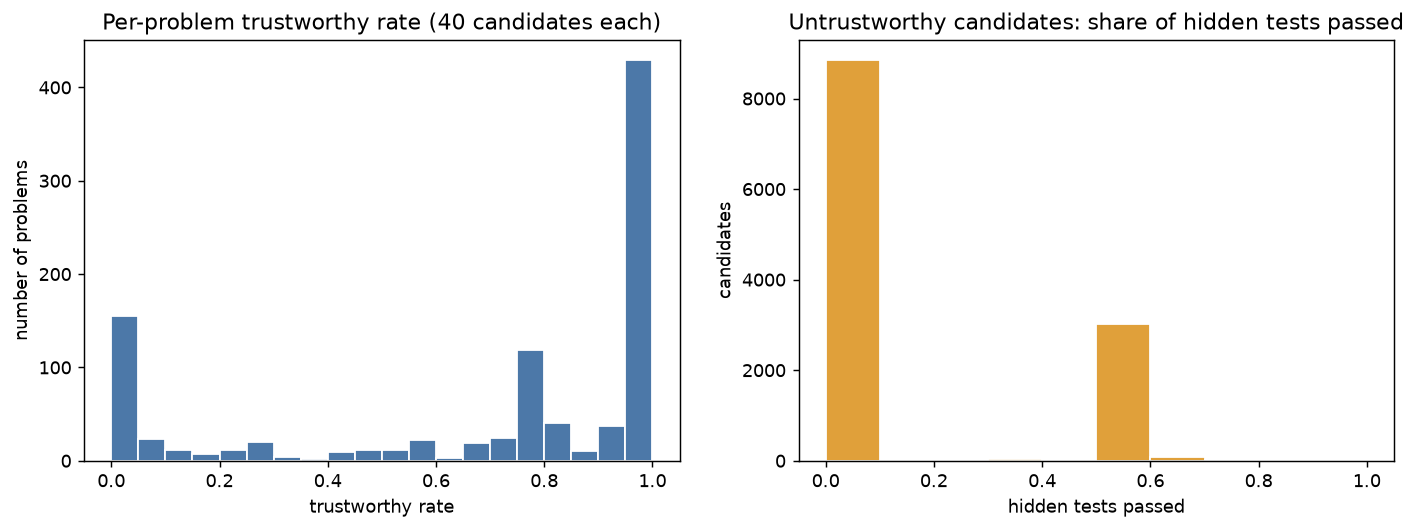

**05_feature_correlations.png**

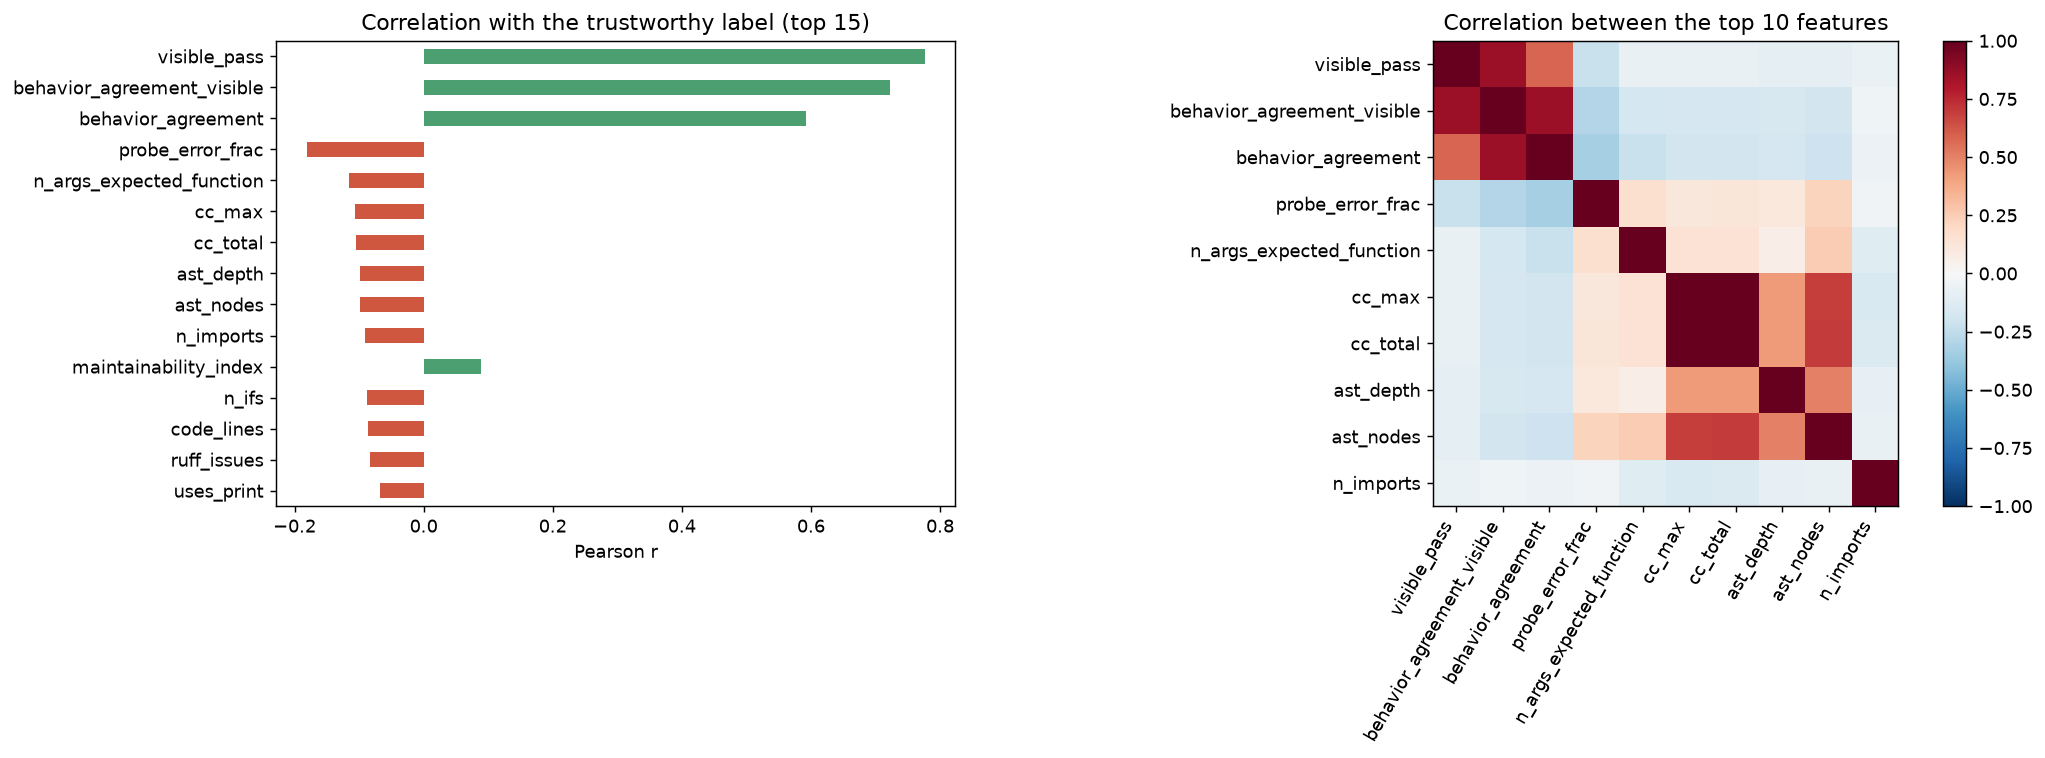

In [8]:
if RUN_EDA:
    from trust_pipeline.eda import run_eda
    run_eda(ARTIFACTS)

eda_dir = os.path.join(ARTIFACTS, "figures", "eda")
for name in ["01_outcomes_by_config.png", "02_trust_and_silent_failures.png", "03_problem_difficulty.png",
             "05_feature_correlations.png"]:
    path = os.path.join(eda_dir, name)
    if os.path.exists(path):
        display(Markdown(f"**{name}**"), Image(path, width=900))

## 5. Train and evaluate the trust model

- **Splits:** grouped by problem into train (60%), calibration (20%) and test (20%).
- **Model selection:** grouped cross-validation on train compares two baselines (majority class and
  visible-test-only) with logistic regression, random forest and gradient boosting.
- **Calibration:** the selected model's probabilities are calibrated on the calibration split.

With `RETRAIN = False` the saved results are loaded.

In [9]:
if RETRAIN:
    from trust_pipeline.pipeline import stage_train
    start = time.time()
    results = stage_train(cfg, paths, dataset, FEATURE_COLUMNS, make_plots=True)
    print(f"Retrained in {time.time() - start:.0f}s")

metrics = json.load(open(paths.metrics))
print("Selected model:", metrics["selected_model"], "| calibration:", metrics["calibration_method"])
display(pd.read_csv(paths.cv_results).round(3))

Selected model: random_forest | calibration: isotonic


,model,cv_roc_auc,cv_roc_auc_std,cv_average_precision,cv_average_precision_std,cv_f1,cv_f1_std,cv_accuracy,cv_accuracy_std
0,majority,0.500,0.000,0.693,0.035,0.818,0.025,0.693,0.035
1,visible_test_only,0.857,0.026,0.888,0.028,0.933,0.016,0.903,0.021
2,logistic_regression,0.924,0.019,0.945,0.016,0.920,0.012,0.889,0.015
3,random_forest,0.940,0.009,0.963,0.012,0.933,0.015,0.906,0.019
4,hist_gradient_boosting,0.928,0.012,0.956,0.015,0.929,0.016,0.900,0.021


### Test-set metrics (194 held-out problems)

Precision, recall and F1 use a 0.5 cutoff; AUROC measures ranking across all cutoffs. The 95% confidence
intervals (bootstrap by problem) are in `run_report.md`.

,accuracy,precision,recall,f1,roc_auc,pr_auc,brier
majority,0.640,0.640,1.000,0.781,0.500,0.640,0.233
visible_test_only,0.886,0.872,0.964,0.916,0.856,0.864,0.101
logistic_regression,0.871,0.895,0.905,0.900,0.920,0.942,0.099
random_forest,0.900,0.900,0.948,0.924,0.941,0.956,0.080
hist_gradient_boosting,0.898,0.900,0.946,0.922,0.931,0.948,0.085
random_forest (calibrated),0.898,0.892,0.956,0.923,0.941,0.957,0.081


AUROC: trust model 0.941 vs visible-test-only 0.856


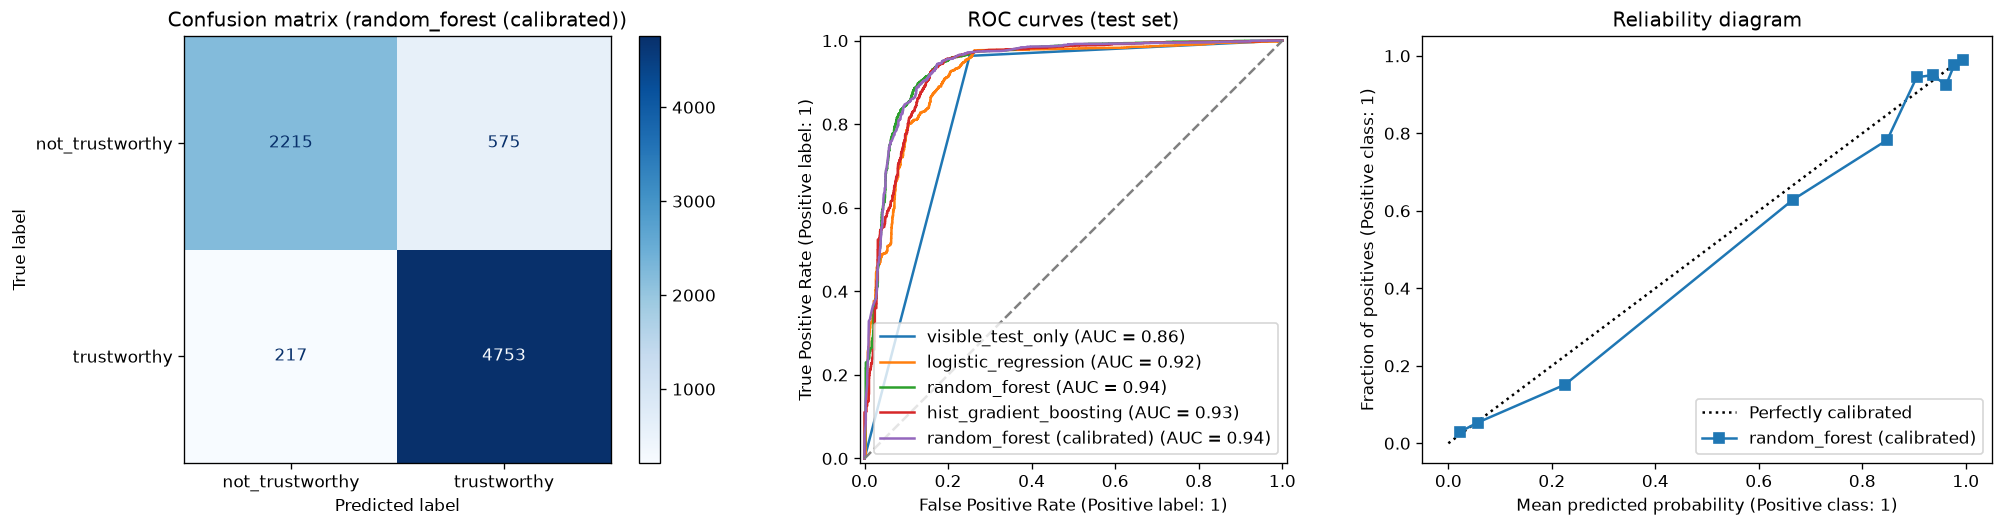

In [10]:
test = pd.DataFrame(metrics["test_metrics"]).T[["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "brier"]]
display(test.round(3))

ours, base = test.loc[f"{metrics['selected_model']} (calibrated)"], test.loc["visible_test_only"]
print(f"AUROC: trust model {ours['roc_auc']:.3f} vs visible-test-only {base['roc_auc']:.3f}")
display(Image(os.path.join(ARTIFACTS, "figures", "evaluation.png"), width=1000))

### What the model relies on

Permutation importance on the test set: how much AUROC drops when a feature is shuffled.

,Unnamed: 0,permutation_importance
0,visible_pass,0.1233
1,behavior_agreement_visible,0.0246
2,behavior_agreement,0.0239
3,ast_nodes,0.0046
4,problem_words,0.0040
5,gen_num_tokens,0.0034
6,code_chars,0.0019
7,gen_mean_logprob,0.0019
8,probe_error_frac,0.0019
9,n_returns,0.0018


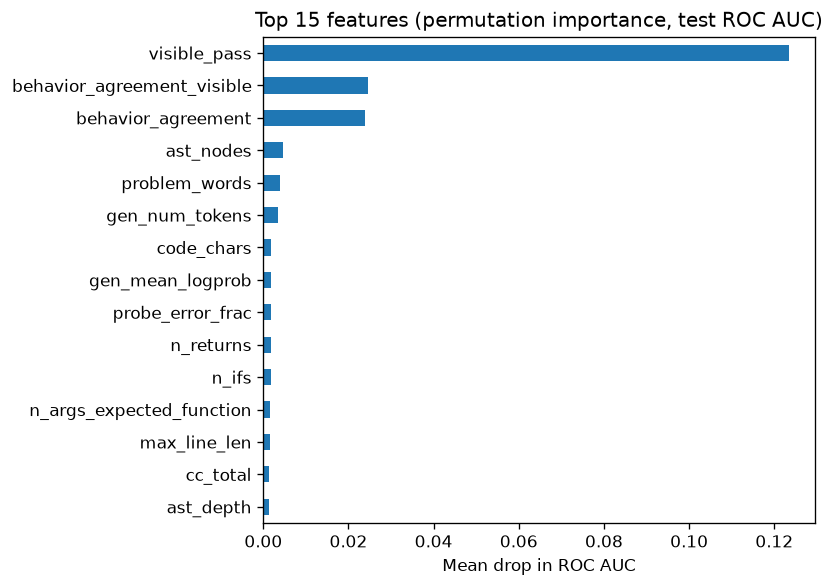

In [11]:
display(pd.read_csv(os.path.join(ARTIFACTS, "feature_importance.csv")).head(10).round(4))
display(Image(os.path.join(ARTIFACTS, "figures", "feature_importance.png"), width=750))

## 6. Three-way decision: APPROVED / REJECTED / NEEDS HUMAN REVIEW

- **Threshold rule:** two thresholds chosen on the calibration split for a 95% precision target.
  Candidates scoring between them go to human review.
- **Conformal:** split-conformal prediction (alpha = 0.10). Prediction sets containing both labels go
  to review.

Threshold rule: APPROVE if p >= 0.789, REJECT if p <= 0.473, else review (target precision 95%)


,threshold_rule,conformal
approved_share,0.604,0.657
rejected_share,0.303,0.279
review_share,0.093,0.064
approved_precision,0.926,0.907
rejected_precision,0.923,0.940
automated_error_rate,0.075,0.083
untrustworthy_code_approved,345.000,473.000


label_trustworthy,not trustworthy,trustworthy,All
decision,,,
APPROVED,345,4341,4686
NEEDS HUMAN REVIEW,272,448,720
REJECTED,2173,181,2354
All,2790,4970,7760


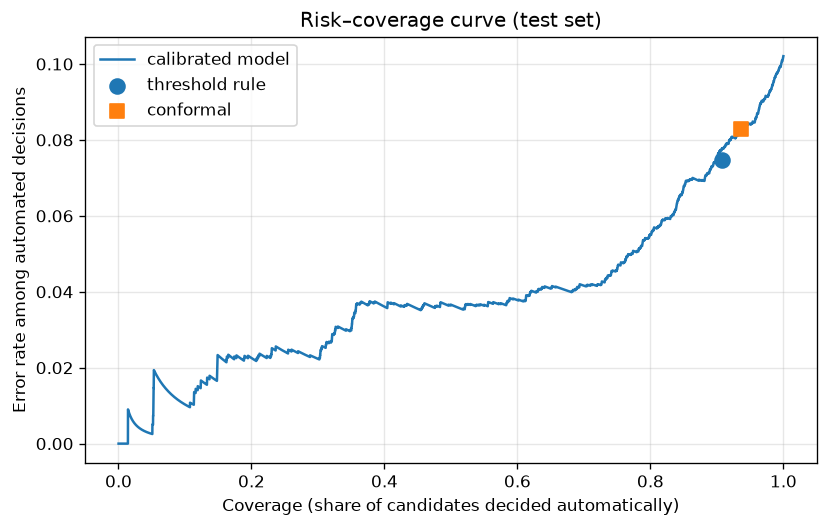

In [12]:
t = metrics["thresholds"]
print(f"Threshold rule: APPROVE if p >= {t['t_high']:.3f}, REJECT if p <= {t['t_low']:.3f}, else review "
      f"(target precision {t['target_approve_precision']:.0%})")
display(pd.DataFrame(metrics["decisions_test"]).round(3))

preds = pd.read_csv(paths.predictions)
display(pd.crosstab(preds["decision"], preds["label_trustworthy"].map({1: "trustworthy", 0: "not trustworthy"}),
                    margins=True))
display(Image(os.path.join(ARTIFACTS, "figures", "risk_coverage.png"), width=750))

In [13]:
# A few example decisions from the test problems
cols = ["task_id", "prompt_style", "exec_status", "visible_pass", "behavior_agreement", "p_trustworthy",
        "decision", "conformal_decision"]
display(pd.concat([g.sample(min(3, len(g)), random_state=42) for _, g in preds.groupby("decision")])[cols].round(3))

,task_id,prompt_style,exec_status,visible_pass,behavior_agreement,p_trustworthy,decision,conformal_decision
6149,755,signature_only,pass,1,1.000,0.956,APPROVED,APPROVED
7753,973,step_by_step,pass,1,1.000,0.902,APPROVED,APPROVED
1383,213,standard,pass,1,1.000,0.976,APPROVED,APPROVED
4490,558,step_by_step,pass,1,0.436,0.759,NEEDS HUMAN REVIEW,APPROVED
3581,452,standard,wrong_output,0,1.000,0.475,NEEDS HUMAN REVIEW,NEEDS HUMAN REVIEW
355,61,constrained,pass,1,0.256,0.711,NEEDS HUMAN REVIEW,APPROVED
6216,767,constrained,runtime_error,0,0.000,0.051,REJECTED,REJECTED
1692,254,step_by_step,wrong_output,0,1.000,0.051,REJECTED,REJECTED
1716,254,constrained,wrong_output,0,1.000,0.037,REJECTED,REJECTED


## 7. Human validation of the labels

A stratified sample of 164 candidates was reviewed blind by a human in the review editor
(`human_edit/app.py`). Agreement with the automated label checks label quality. It is not training data.

In [14]:
agreement = json.load(open(paths.human_agreement))
print(f"Reviewed rows: {agreement['reviewed_rows']}, simulated: {agreement['simulated']}")
print(f"Raw agreement: {agreement['raw_agreement']:.1%},  Cohen's kappa: {agreement['cohen_kappa']:.3f}")
display(pd.DataFrame(agreement["confusion"]).T)

review = pd.read_csv(paths.human_review, keep_default_na=False)
review["human"] = (review["human_trustworthy"] == "yes").astype(int)
review["agree"] = review["human"] == review["label_trustworthy"]
display(review.groupby("exec_status")["agree"].agg(agreement="mean", rows="size").round(3))
display(review.loc[~review["agree"], ["task_id", "exec_status", "label_trustworthy", "human_trustworthy",
                                      "human_notes"]].head(10))

Reviewed rows: 164, simulated: False
Raw agreement: 88.4%,  Cohen's kappa: 0.738


,human=0,human=1
auto=0,44,16
auto=1,3,101


,agreement,rows
exec_status,,
pass,0.971,104
runtime_error,0.833,6
syntax_error,1.000,6
timeout,0.667,6
wrong_output,0.690,42


,task_id,exec_status,label_trustworthy,human_trustworthy,human_notes
11,188,pass,1,no,5X5 = 25 the function failed
19,20,timeout,0,yes,Tested by Hatem
33,310,pass,1,no,"fail (assertion is false)\nassert string_to_tuple(""python 3.0"")==('p', 'y', 't', 'h', 'o', 'n', '3', '.', '0')"
41,360,wrong_output,0,yes,
51,409,runtime_error,0,yes,
64,478,wrong_output,0,yes,Runtime Error
65,47,wrong_output,0,yes,
70,501,wrong_output,0,yes,
71,501,wrong_output,0,yes,
73,508,wrong_output,0,yes,


## 8. Score code with the trained model

`TrustRecommender` runs the decision-time pipeline on code: the visible test, probes, static analysis,
agreement with sibling attempts, then the calibrated model.

The demo below takes a **test problem** (never seen in training) where `gpt-4o-mini` produced both a
correct answer and a **silent failure** (passes the visible test, fails hidden tests). Each is scored
with the other 39 real attempts at the same problem as its siblings.

The example is chosen to show the model working. It is not perfect: on the test problems it still
approved 345 untrustworthy candidates (section 6).

In [15]:
from trust_pipeline.recommendation import TrustRecommender

if not os.path.exists(MODEL_PATH):
    print("Skipped: trust_model.joblib not found. Run `uv run trust-train --output-dir "
          f"{ARTIFACTS}` (~4 min), then rerun this cell.")
else:
    start = time.time()
    recommender = TrustRecommender.load(os.path.join(ARTIFACTS, "trust_model.joblib"))
    print(f"Model loaded in {time.time() - start:.1f}s")

    # A test problem where the saved predictions approved a correct attempt and caught a silent failure
    silent_caught = preds[(preds["visible_pass"] == 1) & (preds["label_trustworthy"] == 0) & (preds["decision"] != "APPROVED")]
    good_approved = preds[(preds["label_trustworthy"] == 1) & (preds["decision"] == "APPROVED")]
    task_id = sorted(set(silent_caught["task_id"]) & set(good_approved["task_id"]))[0]
    attempts = dataset[dataset["task_id"] == task_id]
    demo = by_id[task_id]
    good = attempts.loc[attempts["candidate_id"].isin(good_approved["candidate_id"])].iloc[0]
    bad = attempts.loc[attempts["candidate_id"].isin(silent_caught["candidate_id"])].iloc[0]

    def score(row):
        siblings = attempts.loc[attempts.index != row.name, "generated_code"].tolist()
        return recommender.recommend(demo, row["generated_code"], siblings, executor)

    print(f"Task {task_id}: {demo['text']}\nVisible test: {demo['visible_tests'][0]}\n")
    print("Correct attempt:\n" + good["generated_code"])
    print("->", score(good), "\n")
    print("Silent failure (passes the visible test, fails hidden tests):\n" + bad["generated_code"])
    print("Hidden results:", bad["hidden_results"])
    print("->", score(bad))


Model loaded in 1.4s
Task 382: Write a function to find the number of rotations in a circularly sorted array.
Visible test: assert find_rotation_count([8, 9, 10, 1, 2, 3, 4, 5, 6, 7]) == 3

Correct attempt:
def find_rotation_count(arr):
    left, right = 0, len(arr) - 1
    
    while left < right:
        mid = (left + right) // 2
        
        if arr[mid] > arr[right]:
            left = mid + 1
        else:
            right = mid
            
    return left
-> {'p_trustworthy': 0.815, 'decision': 'APPROVED', 'conformal_decision': 'APPROVED', 'visible_pass': 1, 'behavior_agreement': 0.487, 'ruff_issues': 3, 'bandit_med_high': 0} 

Silent failure (passes the visible test, fails hidden tests):
def find_rotation_count(arr):
    def binary_search_low(arr, low, high):
        if high < low:
            return 0
        if high == low:
            return low
        mid = (low + high) // 2
        if mid < high and arr[mid] > arr[mid + 1]:
            return mid + 1
        if mid > 

Score your own file from the terminal:

```bash
uv run trust-recommend --output-dir artifacts_pilot_openai --task-id 17 --code-file my_solution.py
```

## 9. Full run report

`run_report.md` has every number from the run (generation, outcomes, pass@k, splits, model selection,
test metrics with CIs, decisions, human review).

In [16]:
display(Markdown(open(paths.run_report_md).read()))

# Run report `20261008-001942-774ca5`

## Run

| Item | Value |
|---|---|
| Run id | 20261008-001942-774ca5 |
| Mode | real |
| Human feedback | real |
| Started | 2026-10-08T00:19:42-04:00 |
| Finished | 2026-10-08T08:39:04-04:00 |
| Wall-clock duration | 8h 19m |
| Problems requested | all |
| Model configs | gpt-4o-mini-t0.3, gpt-4o-mini-t1.0 |
| Prompt styles | standard, signature_only, step_by_step, constrained |
| Samples per config | 5 |
| Seed | 42 |
| Output dir | `/Users/hatem/MLE_NEW/artifacts_pilot_openai` |
| Commands | trust-pipeline --no-local-hf --openai --all-problems --prompt-styles natural --samples-per-config 5 --human-feedback real --output-dir artifacts_pilot_openai; trust-generate --output-dir artifacts_pilot_openai; trust-label --output-dir artifacts_pilot_openai; trust-label --output-dir artifacts_pilot_openai; trust-features --output-dir artifacts_pilot_openai; trust-train --output-dir artifacts_pilot_openai; trust-train --output-dir artifacts_pilot_openai; trust-review --output-dir artifacts_pilot_openai; trust-review --output-dir artifacts_pilot_openai; trust-review --output-dir artifacts_pilot_openai |
| Python / platform | 3.12.12 / macOS-15.7.4-x86_64-i386-64bit |
| GPU | not checked |
| Package versions | mle-trust-pipeline 0.1.0, scikit-learn 1.9.1, numpy 2.5.3, pandas 3.0.6, datasets 5.1.0, openai 3.24.0, anthropic 1.11.0 |

## Stage timings

| Stage | Time | Seconds |
|---|---|---|
| prepare | 18s | 17.5 |
| generate | 4s | 4.1 |
| execute | 20m 36s | 1236.4 |
| static | 1m 41s | 101.1 |
| features | 57s | 56.5 |
| human | 0s | 0.1 |
| train | 2m 42s | 162.4 |
| decide | 3m 43s | 222.8 |
| **total** | 30m 01s | 1801.1 |

## Generation (per model config and prompt style)

New / reused / failed refer to the latest generate session; tokens and latency cover every sample in the dataset that recorded them. Local models generate the samples for a problem in one batch, so seconds per sample is the batch time divided by the batch size.

| Config | Model | Temp | Prompt style | Provenance | Problems | Samples | New | Reused | Failed | Out tokens (total) | Out tokens (mean) | In tokens (total) | s / sample | tokens / s |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| gpt-4o-mini-t0.3 | gpt-4o-mini | 0.3 | standard | natural | 968 | 4,840 | 0 | 4,840 | 0 | 244866 | 50.6 | 115334 | 0.31 | 165.3 |
| gpt-4o-mini-t0.3 | gpt-4o-mini | 0.3 | signature_only | natural | 968 | 4,840 | 0 | 4,840 | 0 | 271458 | 56.1 | 86970 | 0.31 | 182.3 |
| gpt-4o-mini-t0.3 | gpt-4o-mini | 0.3 | step_by_step | natural | 968 | 4,840 | 0 | 4,840 | 0 | 1151437 | 237.9 | 128886 | 0.89 | 266.3 |
| gpt-4o-mini-t0.3 | gpt-4o-mini | 0.3 | constrained | natural | 968 | 4,840 | 0 | 4,840 | 0 | 204313 | 42.2 | 146310 | 0.28 | 150.9 |
| gpt-4o-mini-t1.0 | gpt-4o-mini | 1.0 | standard | natural | 968 | 4,840 | 0 | 4,840 | 0 | 247723 | 51.2 | 115334 | 0.31 | 166.2 |
| gpt-4o-mini-t1.0 | gpt-4o-mini | 1.0 | signature_only | natural | 968 | 4,840 | 0 | 4,840 | 0 | 274703 | 56.8 | 86970 | 0.32 | 177.9 |
| gpt-4o-mini-t1.0 | gpt-4o-mini | 1.0 | step_by_step | natural | 968 | 4,840 | 0 | 4,840 | 0 | 1161077 | 239.9 | 128886 | 0.88 | 271.6 |
| gpt-4o-mini-t1.0 | gpt-4o-mini | 1.0 | constrained | natural | 968 | 4,840 | 0 | 4,840 | 0 | 203842 | 42.1 | 146310 | 0.27 | 154.5 |

## Execution outcomes and labels

Outcome on the hidden tests. Trustworthy = passes every hidden test and has no medium/high-severity bandit finding. Config = model config, plus `/style` for non-standard prompt styles.

Provenance: natural 38,720. `natural` = LLM output from a normal prompt; `injected` = LLM asked for a subtle bug (training only); `mutant` / `reference` = mutated / original reference solutions.

| Config | Temp | Prompt style | Provenance | Rows | pass | wrong_output | runtime_error | timeout | syntax_error | generation_error | Trustworthy |
|---|---|---|---|---|---|---|---|---|---|---|---|
| gpt-4o-mini-t0.3 | 0.3 | standard | natural | 4,840 | 3,590 | 1,203 | 41 | 1 | 5 | 0 | 74.0% |
| gpt-4o-mini-t0.3/signature_only | 0.3 | signature_only | natural | 4,840 | 2,672 | 1,731 | 437 | 0 | 0 | 0 | 55.1% |
| gpt-4o-mini-t0.3/step_by_step | 0.3 | step_by_step | natural | 4,840 | 3,626 | 1,124 | 81 | 8 | 1 | 0 | 74.9% |
| gpt-4o-mini-t0.3/constrained | 0.3 | constrained | natural | 4,840 | 3,525 | 1,240 | 65 | 5 | 5 | 0 | 72.8% |
| gpt-4o-mini-t1.0 | 1.0 | standard | natural | 4,840 | 3,572 | 1,194 | 59 | 6 | 9 | 0 | 73.7% |
| gpt-4o-mini-t1.0/signature_only | 1.0 | signature_only | natural | 4,840 | 2,654 | 1,737 | 439 | 7 | 3 | 0 | 54.7% |
| gpt-4o-mini-t1.0/step_by_step | 1.0 | step_by_step | natural | 4,840 | 3,586 | 1,146 | 98 | 4 | 6 | 0 | 74.1% |
| gpt-4o-mini-t1.0/constrained | 1.0 | constrained | natural | 4,840 | 3,495 | 1,249 | 81 | 8 | 7 | 0 | 72.2% |
| **all** | – | – | – | 38,720 | 26,720 | 10,624 | 1,301 | 39 | 36 | 0 | 68.9% |

### Failure-mode coverage (rows showing each failure mode)

Target: every failure mode is present. The last column is the dangerous silent failure.

| Prompt style | Provenance | Rows | Syntax error | Runtime error | Timeout | Wrong output | Security finding | Visible pass, hidden fail | Trustworthy |
|---|---|---|---|---|---|---|---|---|---|
| standard | natural | 9,680 | 14 | 100 | 7 | 2,397 | 14 | 892 | 7,148 |
| signature_only | natural | 9,680 | 3 | 876 | 7 | 3,468 | 10 | 445 | 5,316 |
| step_by_step | natural | 9,680 | 7 | 179 | 12 | 2,270 | 0 | 855 | 7,212 |
| constrained | natural | 9,680 | 12 | 146 | 13 | 2,489 | 11 | 910 | 7,019 |
| all | all | 38,720 | 36 | 1,301 | 39 | 10,624 | 35 | 3,102 | 26,695 |

### pass@k on hidden tests (unbiased estimator)

| Config | pass@1 | pass@3 | pass@5 |
|---|---|---|---|
| gpt-4o-mini-t0.3 | 74.2% | 75.8% | 76.4% |
| gpt-4o-mini-t0.3/signature_only | 55.2% | 57.1% | 57.7% |
| gpt-4o-mini-t0.3/step_by_step | 74.9% | 77.7% | 78.9% |
| gpt-4o-mini-t0.3/constrained | 72.8% | 74.8% | 75.5% |
| gpt-4o-mini-t1.0 | 73.8% | 77.7% | 79.2% |
| gpt-4o-mini-t1.0/signature_only | 54.8% | 59.4% | 61.1% |
| gpt-4o-mini-t1.0/step_by_step | 74.1% | 79.5% | 81.1% |
| gpt-4o-mini-t1.0/constrained | 72.2% | 77.6% | 79.4% |

### Visible test vs hidden tests

**10.6% of candidates that pass the visible test still fail at least one hidden test.**

|  | Hidden pass | Hidden fail |
|---|---|---|
| Visible pass | 26,184 | 3,102 |
| Visible fail | 536 | 8,898 |

| Config | Visible pass | Hidden pass | Hidden fail given visible pass |
|---|---|---|---|
| gpt-4o-mini-t0.3 | 82.0% | 74.2% | 11.3% |
| gpt-4o-mini-t0.3/signature_only | 58.9% | 55.2% | 7.8% |
| gpt-4o-mini-t0.3/step_by_step | 82.1% | 74.9% | 10.5% |
| gpt-4o-mini-t0.3/constrained | 80.6% | 72.8% | 11.8% |
| gpt-4o-mini-t1.0 | 81.5% | 73.8% | 11.3% |
| gpt-4o-mini-t1.0/signature_only | 58.4% | 54.8% | 7.9% |
| gpt-4o-mini-t1.0/step_by_step | 81.5% | 74.1% | 11.1% |
| gpt-4o-mini-t1.0/constrained | 80.0% | 72.2% | 11.6% |
| **all** | 75.6% | 69.0% | 10.6% |

### Static analysis

| Config | With ruff issues | With undefined names | With bandit medium/high | Mean ruff issues |
|---|---|---|---|---|
| gpt-4o-mini-t0.3 | 19.3% | 0.0% | 0.2% | 0.43 |
| gpt-4o-mini-t0.3/signature_only | 24.5% | 0.0% | 0.1% | 0.55 |
| gpt-4o-mini-t0.3/step_by_step | 38.2% | 0.1% | 0.0% | 1.04 |
| gpt-4o-mini-t0.3/constrained | 14.1% | 0.2% | 0.1% | 0.18 |
| gpt-4o-mini-t1.0 | 20.4% | 0.0% | 0.1% | 0.43 |
| gpt-4o-mini-t1.0/signature_only | 25.2% | 0.1% | 0.1% | 0.53 |
| gpt-4o-mini-t1.0/step_by_step | 40.0% | 0.0% | 0.0% | 0.98 |
| gpt-4o-mini-t1.0/constrained | 14.9% | 0.2% | 0.1% | 0.20 |
| **all** | 24.6% | 0.1% | 0.1% | 0.54 |

## Dataset and splits

Splits are by problem: no problem appears in two splits.

| Split | Rows | Problems | Trustworthy | Rate | natural |
|---|---|---|---|---|---|
| train | 23,200 | 580 | 16,086 | 69.3% | 23,200 |
| calibration | 7,760 | 194 | 5,639 | 72.7% | 7,760 |
| test | 7,760 | 194 | 4,970 | 64.0% | 7,760 |
| **total** | 38,720 | 968 | 26,695 | 68.9% | 38,720 |

## Model selection (grouped cross-validation on train, mean ± std)

| Model | roc_auc | average_precision | f1 | accuracy |
|---|---|---|---|---|
| majority | 0.500 ± 0.000 | 0.693 ± 0.035 | 0.818 ± 0.025 | 0.693 ± 0.035 |
| visible_test_only | 0.857 ± 0.026 | 0.888 ± 0.028 | 0.933 ± 0.016 | 0.903 ± 0.021 |
| logistic_regression | 0.924 ± 0.019 | 0.945 ± 0.016 | 0.920 ± 0.012 | 0.889 ± 0.015 |
| **random_forest** | 0.940 ± 0.009 | 0.963 ± 0.012 | 0.933 ± 0.015 | 0.906 ± 0.019 |
| hist_gradient_boosting | 0.928 ± 0.012 | 0.956 ± 0.015 | 0.929 ± 0.016 | 0.900 ± 0.021 |

Selected: **random_forest**, calibrated with isotonic calibration. Baselines: majority, visible_test_only.

## Test-set metrics (held-out problems, 95% CI from 1000 bootstrap resamples by problem)

Threshold 0.5 for accuracy / precision / recall / F1; lower Brier is better.

| Model | accuracy | precision | recall | f1 | roc_auc | pr_auc | brier |
|---|---|---|---|---|---|---|---|
| majority | 0.640 [0.583, 0.703] | 0.640 [0.583, 0.703] | 1.000 [1.000, 1.000] | 0.781 [0.737, 0.825] | 0.500 [0.500, 0.500] | 0.640 [0.583, 0.703] | 0.233 [0.209, 0.255] |
| visible_test_only | 0.886 [0.848, 0.922] | 0.872 [0.824, 0.919] | 0.964 [0.932, 0.988] | 0.916 [0.885, 0.944] | 0.856 [0.816, 0.898] | 0.864 [0.815, 0.912] | 0.101 [0.071, 0.131] |
| logistic_regression | 0.871 [0.835, 0.906] | 0.895 [0.847, 0.940] | 0.905 [0.868, 0.937] | 0.900 [0.868, 0.929] | 0.920 [0.884, 0.953] | 0.942 [0.909, 0.970] | 0.099 [0.075, 0.124] |
| random_forest | 0.900 [0.868, 0.932] | 0.900 [0.857, 0.940] | 0.948 [0.919, 0.973] | 0.924 [0.896, 0.949] | 0.941 [0.909, 0.968] | 0.956 [0.926, 0.983] | 0.080 [0.059, 0.102] |
| hist_gradient_boosting | 0.898 [0.864, 0.929] | 0.900 [0.857, 0.940] | 0.946 [0.915, 0.970] | 0.922 [0.893, 0.948] | 0.931 [0.896, 0.961] | 0.948 [0.913, 0.977] | 0.085 [0.058, 0.115] |
| **random_forest (calibrated)** | 0.898 [0.864, 0.930] | 0.892 [0.849, 0.934] | 0.956 [0.929, 0.977] | 0.923 [0.895, 0.949] | 0.941 [0.910, 0.968] | 0.957 [0.927, 0.982] | 0.081 [0.058, 0.104] |

### Test metrics of random_forest (calibrated) by prompt style (natural samples only)

| Prompt style | Rows | Problems | Trustworthy rate | accuracy | precision | recall | f1 | roc_auc | pr_auc | brier |
|---|---|---|---|---|---|---|---|---|---|---|
| standard | 1,940 | 194 | 67.8% | 0.888 | 0.882 | 0.964 | 0.921 | 0.937 | 0.965 | 0.091 |
| signature_only | 1,940 | 194 | 51.5% | 0.943 | 0.938 | 0.953 | 0.945 | 0.963 | 0.960 | 0.052 |
| step_by_step | 1,940 | 194 | 69.7% | 0.876 | 0.888 | 0.942 | 0.914 | 0.916 | 0.953 | 0.093 |
| constrained | 1,940 | 194 | 67.1% | 0.884 | 0.874 | 0.967 | 0.918 | 0.932 | 0.950 | 0.087 |

## Three-way decisions on the test split

Threshold rule (chosen on the calibration split, target precision 0.95 / 0.95): APPROVE if p ≥ 0.789; REJECT if p ≤ 0.473; otherwise NEEDS HUMAN REVIEW. Conformal (alpha 0.10): qhat 0.333, test coverage 0.859.

| Metric | threshold_rule | conformal |
|---|---|---|
| approved share | 60.4% | 65.7% |
| rejected share | 30.3% | 27.9% |
| review share | 9.3% | 6.4% |
| approved precision | 92.6% | 90.7% |
| rejected precision | 92.3% | 94.0% |
| automated error rate | 7.5% | 8.3% |
| untrustworthy code approved | 345 | 473 |

## Human review agreement

| Item | Value |
|---|---|
| Reviewer | real reviewers |
| Reviewed rows | 164 |
| Raw agreement | 88.4% |
| Cohen's kappa | 0.738 |

## Files

`run_report.json` has every number above (machine-readable). Other outputs in the same folder: `metrics.json`, `cv_results.csv`, `model_comparison.csv`, `test_predictions.csv`, `feature_importance.csv`, `figures/`. Cross-run history: `/Users/hatem/MLE_NEW/runs_history.csv`.


## 10. Methodology note for your write-up

> We use MBPP, a function-level Python benchmark with crowd-sourced problem statements and unit
> tests, as the task source. For each problem, one test is shown to the generating model
> (*visible*) and the remaining tests, including MBPP's challenge tests, are held back (*hidden*).
> Candidate solutions are sampled from several models and temperatures to obtain a realistic mix of
> correct and incorrect code. Each candidate is labelled **trustworthy** if it passes every hidden
> test in a sandboxed subprocess and has no medium- or high-severity Bandit finding; no AI model is
> asked to judge the code. A stratified sample was reviewed by the team to check that this label
> agrees with human judgments of trustworthiness (Cohen's kappa).
>
> The classifier only sees information available before the hidden tests are run: AST structure and
> complexity, lint and security findings, whether the visible test passes, agreement of the
> candidate's behaviour with sibling samples on probe inputs derived from the visible test, and the
> generating model's token log-probabilities. Data are split by problem into training (60%),
> calibration (20%) and test (20%) sets. Models are compared with grouped cross-validation against a
> majority-class and a visible-test-only baseline, and the selected model's probabilities are
> calibrated. We report accuracy, precision, recall, F1, ROC AUC, PR AUC and Brier score on the
> test set. A three-way recommendation (APPROVED / REJECTED / NEEDS HUMAN REVIEW) is produced from
> thresholds chosen on the calibration set to reach a target precision, and alternatively from
> split-conformal prediction; we report the share of candidates decided automatically and the error
> rate among those decisions (risk–coverage).

**Limitations to disclose**
- MBPP problems are short, isolated functions; results may not transfer to repository-level code.
- MBPP's hidden tests are few (usually two per problem), so some "passing" code is still wrong.
- MBPP is old enough to be in many models' training data; a LiveCodeBench slice (problems published
  after the models' training cut-off) would test for contamination.
- Bandit rarely fires on MBPP-style code, so the security part of the label is mostly inactive.
- Log-probabilities are computed after temperature / top-p adjustments and aren't available for
  Anthropic models; they are imputed.
- Mutant augmentation (if enabled) produces bugs with a different "style" from natural model errors;
  mutants are therefore used for training only, never for calibration or testing.
- If `HUMAN_ADDED_FEEDBACK = True` or `SMOKE_TEST = True` produced any reported number, say so:
  those runs show the pipeline works, not a finding about trustworthiness.